In [ ]:
!uv pip install -q torchaudio
!uv pip install -q torchcodec
!uv pip install -q torch
!uv pip install -q tensorflow tensorflow-io
!uv pip install -q tensorflow_hub
!uv pip install -q datasets[audio]
!uv pip install -q protobuf

In [ ]:
import os

from IPython import display
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

import tensorflow as tf
import tensorflow_hub as hub
import tensorflow_io as tfio


/usr/local/lib/python3.12/dist-packages/tensorflow_io/python/ops/__init__.py:98: UserWarning: unable to load libtensorflow_io_plugins.so: unable to open file: libtensorflow_io_plugins.so, from paths: ['/usr/local/lib/python3.12/dist-packages/tensorflow_io/python/ops/libtensorflow_io_plugins.so']
caused by: ['/usr/local/lib/python3.12/dist-packages/tensorflow_io/python/ops/libtensorflow_io_plugins.so: undefined symbol: _ZN3tsl5mutex6unlockEv']
  warnings.warn(f"unable to load libtensorflow_io_plugins.so: {e}")
/usr/local/lib/python3.12/dist-packages/tensorflow_io/python/ops/__init__.py:104: UserWarning: file system plugins are not loaded: unable to open file: libtensorflow_io.so, from paths: ['/usr/local/lib/python3.12/dist-packages/tensorflow_io/python/ops/libtensorflow_io.so']
caused by: ['/usr/local/lib/python3.12/dist-packages/tensorflow_io/python/ops/libtensorflow_io.so: undefined symbol: _ZNK10tensorflow4data11DatasetBase8FinalizeEPNS_15OpKernelContextESt8functionIFN4absl12lts_202

In [ ]:
from datasets import load_dataset

# Login using e.g. `huggingface-cli login` to access this dataset
ds = load_dataset("BigTrev89/wingbeats-insect-audio")

README.md:   0%|          | 0.00/366 [00:00<?, ?B/s]

data/train-00000-of-00006.parquet: reconstructing file:   0%|          |  0.00B /  468MB            

data/train-00000-of-00006.parquet: downloading bytes:           |  0.00B            

data/train-00001-of-00006.parquet: reconstructing file:   0%|          |  0.00B /  467MB            

data/train-00001-of-00006.parquet: downloading bytes:           |  0.00B            

...

data/train-00004-of-00006.parquet: reconstructing file:   0%|          |  0.00B /  468MB            

data/train-00004-of-00006.parquet: downloading bytes:           |  0.00B            

data/train-00005-of-00006.parquet: reconstructing file:   0%|          |  0.00B /  467MB            

data/train-00005-of-00006.parquet: downloading bytes:           |  0.00B            

Generating train split:   0%|          | 0/279566 [00:00<?, ? examples/s]

In [ ]:
ds

DatasetDict({
    train: Dataset({
        features: ['file_name', 'label', 'sub_folder'],
        num_rows: 279566
    })
})

In [ ]:
from collections import Counter
import seaborn as sns
import matplotlib.pyplot as plt


species_counts = Counter(ds['train']['label'])

# Sort the data for the plot
sorted_counts = dict(sorted(species_counts.items(), key=lambda item: item[1], reverse=True))
species_labels = list(sorted_counts.keys())
counts = list(sorted_counts.values())

print(f"Total unique species: {len(species_labels)}")

Total unique species: 6


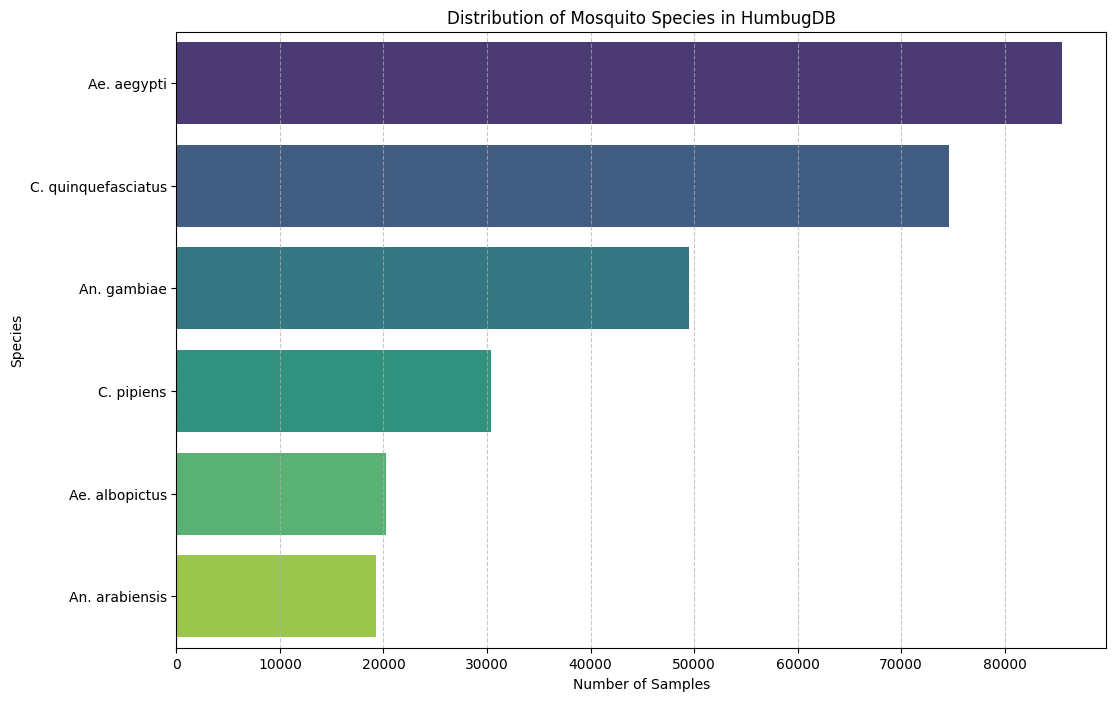

In [ ]:
plt.figure(figsize=(12, 8))
sns.barplot(y=species_labels, x=counts, hue=species_labels, palette='viridis', legend=False)
plt.title('Distribution of Mosquito Species in HumbugDB')
plt.xlabel('Number of Samples')
plt.ylabel('Species')
plt.grid(axis='x', linestyle='--', alpha=0.7)
plt.show()

In [ ]:
from collections import Counter

# Extract genus (first word) from each label
genera = [label.split()[0] if label and isinstance(label, str) else 'Unknown' for label in ds['train']['label']]
genus_counts = Counter(genera)

# Sort for visualization
sorted_genus = dict(sorted(genus_counts.items(), key=lambda item: item[1], reverse=True))
genus_names = list(sorted_genus.keys())
genus_values = list(sorted_genus.values())

print(f"Unique genera found: {genus_names}")

Unique genera found: ['Ae.', 'C.', 'An.']


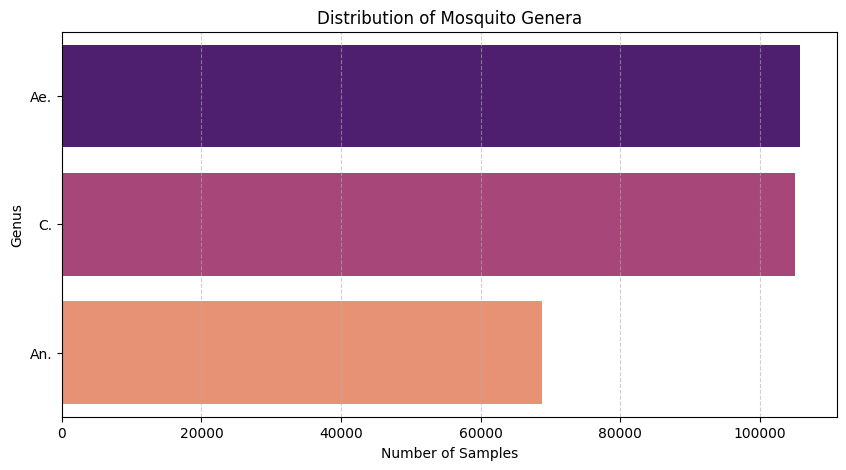

In [ ]:
import seaborn as sns
import matplotlib.pyplot as plt

plt.figure(figsize=(10, 5))
sns.barplot(x=genus_values, y=genus_names, hue=genus_names, palette='magma', legend=False)
plt.title('Distribution of Mosquito Genera')
plt.xlabel('Number of Samples')
plt.ylabel('Genus')
plt.grid(axis='x', linestyle='--', alpha=0.6)
plt.show()